In [ ]:
import pandas as pd
import numpy as np

In [ ]:
micro_data = np.array([0.34, 0.35, 0.36 ,0.36 ,0.37 ,0.36 ,0.36 ,0.36 ,0.36 ,0.36])
sigma = (((micro_data - np.mean(micro_data))**2).sum())**(1/2)/len(micro_data)
sigma


np.float64(0.0023664319132398444)

In [ ]:
'''
1 & 147 & 358.8 &  & 358.8 |  & 149 & 245.7 & f & 245.7 | & 150 & 148.2 & f & 148.2\\
\midrule
2 & 136 & 333.4 & f & 333.4 | & 123 & 203.0 & f & 203.0 | & 131 & 129.9 & f & 129.9\\
\midrule
3 & 117 & 286.2 & f & 286.2 | & 101 & 174.9 & f & 174.9 | & 124 & 122.2 & f & 122.2\\
\midrule
4 & 98 & 239.2 & f & 239.5 | & 95 & 156.7 & f & 156.7 | & 109 & 107.9 & f & 107.9\\
\midrule
5 & 79 & 191.5 & f & 191.5 | & 83 & 136.7 & f & 136.7 | & 95 & 094.2 & f & 094.2\\
\midrule
6 & 67 & 164.1 & f & 164.1 | & 66 & 109.0 & f & 109.0 | & 87 & 085.7 & f & 085.7\\
\midrule
7 & 59 & 131.5 & f & 131.5 | & 50 & 083.3 & f & 083.3 | & 82 & 081.0 & f & 081.0\\
\midrule
8 & 43 & 106.3 & f & 106.3 | & 45 & 075.2 & f & 075.2 | & 75 & 074.6 & f & 074.6\\
\midrule
9 & 30 & 073.6 & f & 073.6 | & 42 & 069.6 & f & 069.9 | & 69 & 068.4 & f & 068.4\\
\midrule
10 & 26 & 065.3 & f & 065.3 | & 39 & 064.1 & f & 064.1 | & 62 & 061.7 & f & 061.7\\
\midrule
'''

In [29]:
length_20 = pd.DataFrame({'I':np.array([358.8, 333.4, 286.2, 239.2, 191.5, 164.1, 131.5, 106.3, 073.6, 065.3]),
'V':5*np.array([147, 136, 117, 98, 79, 67, 59, 43, 30, 26])})

length_30 = pd.DataFrame({'I':np.array([245.7, 203.0, 174.9, 156.7, 136.7, 109.0, 083.3, 075.2, 069.9, 064.1]),
'V':5*np.array([149, 123, 101, 95 ,83, 66, 50, 45, 42, 39])})

length_50 = pd.DataFrame({'I':np.array([148.2, 129.9, 122.2, 107.9, 094.2, 085.7, 081.0, 074.6, 068.4, 061.7]),
'V':5*np.array([150, 131, 124, 109, 95, 87, 82, 75, 69 ,62])})

In [52]:
print(length_20['V'])
print(length_30['V'])
print(length_50['V'])

0    735
1    680
2    585
3    490
4    395
5    335
6    295
7    215
8    150
9    130
Name: V, dtype: int64
0    745
1    615
2    505
3    475
4    415
5    330
6    250
7    225
8    210
9    195
Name: V, dtype: int64
0    750
1    655
2    620
3    545
4    475
5    435
6    410
7    375
8    345
9    310
Name: V, dtype: int64


Text(0, 0.5, 'V, мВ')

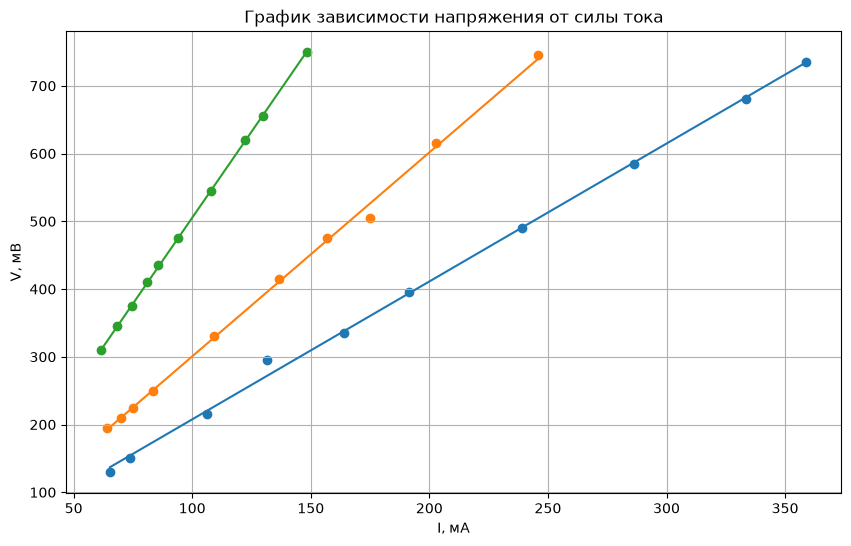

In [51]:
k_20, b_20 = np.polyfit(length_20['I'], length_20['V'], deg=1)
k_30, b_30 = np.polyfit(length_30['I'], length_30['V'], deg=1)
k_50, b_50 = np.polyfit(length_50['I'], length_50['V'], deg=1)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
plt.grid(True)
ax.scatter(length_20['I'], length_20['V'])
ax.plot(length_20['I'], length_20['I']*k_20 + b_20)
ax.scatter(length_30['I'], length_30['V'])
ax.plot(length_30['I'], length_30['I']*k_30 + b_30)
ax.scatter(length_50['I'], length_50['V'])
ax.plot(length_50['I'], length_50['I']*k_50 + b_50)

ax.set_title('График зависимости напряжения от силы тока')
ax.set_xlabel('I, мА')
ax.set_ylabel('V, мВ')

In [63]:
r_20 = np.mean(length_20['V']*length_20['I'])/np.mean(length_20['I']*length_20['I'])
r_30 = np.mean(length_30['V']*length_30['I'])/np.mean(length_30['I']*length_30['I'])
r_50 = np.mean(length_50['V']*length_50['I'])/np.mean(length_50['I']*length_50['I'])
print(r_20, r_30, r_50)

sigma_random_20 = 1/10**(1/2)*((np.mean(length_20['V']*length_20['V']))/(np.mean(length_20['I']*length_20['I'])) - r_20**2)**(1/2)
sigma_random_30 = 1/10**(1/2)*((np.mean(length_30['V']*length_30['V']))/(np.mean(length_30['I']*length_30['I'])) - r_30**2)**(1/2)
sigma_random_50 = 1/10**(1/2)*((np.mean(length_50['V']*length_50['V']))/(np.mean(length_50['I']*length_50['I'])) - r_50**2)**(1/2)
print(sigma_random_20,sigma_random_30,sigma_random_50)

sigma_system_20 = r_20*((0.9375/735)**2 + (0.005/358.8)**2)**(1/2)
sigma_system_30 = r_30*((0.9375/745)**2 + (0.005/245.7)**2)**(1/2)
sigma_system_50 = r_50*((0.9375/750)**2 + (0.005/148.2)**2)**(1/2)
print(sigma_system_20,sigma_system_30,sigma_system_50)

sigma_res_20 = (sigma_random_20**2 + sigma_system_20**2)**(1/2)
sigma_res_30 = (sigma_random_30**2 + sigma_system_30**2)**(1/2)
sigma_res_50 = (sigma_random_50**2 + sigma_system_50**2)**(1/2)
print(sigma_res_20, sigma_res_30, sigma_res_50)


2.052129436472847 3.007829459951054 5.054060826523362
0.011993180583898635 0.016055785961860476 0.004658643695651836
0.0026176682478157346 0.0037855151845148775 0.006319876759596882
0.012275527181087821 0.01649601127743518 0.00785135678335467


In [50]:
ax.set_ylabel?

Signature: ax.set_ylabel(ylabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)
Docstring:
Set the label for the y-axis.

Parameters
----------
ylabel : str
    The label text.

labelpad : float, default: :rc:`axes.labelpad`
    Spacing in points from the Axes bounding box including ticks
    and tick labels.  If None, the previous value is left as is.

loc : {'bottom', 'center', 'top'}, default: :rc:`yaxis.labellocation`
    The label position. This is a high-level alternative for passing
    parameters *y* and *horizontalalignment*.

Other Parameters
----------------
**kwargs : `~matplotlib.text.Text` properties
    `.Text` properties control the appearance of the label.

See Also
--------
text : Documents the properties supported by `.Text`.
File:      ~/miniconda3/envs/MIPT/lib/python3.12/site-packages/matplotlib/axes/_base.py
Type:      method